## 1. Carga de Datos y Preprocesamiento

1. Cargando datos...
4. Construyendo modelo simplificado...


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input_Secuencial    │ (None, 20, 24)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 32)        │      7,296 │ Input_Secuencial… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Input_FED           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 8)         │         16 │ Input_FED[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 40)        │          0 │ dropout_2[0][0],  │
│ (Concatenate)       │                   │            │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │      2,624 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 60)        │      3,900 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 5, 12)     │          0 │ dense_8[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 13,836 (54.05 KB)

 Trainable params: 13,836 (54.05 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.3646 - val_loss: 0.2933 - learning_rate: 0.0010
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3621 - val_loss: 0.2926 - learning_rate: 0.0010
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3613 - val_loss: 0.2923 - learning_rate: 0.0010
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3607 - val_loss: 0.2921 - learning_rate: 0.0010
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3603 - val_loss: 0.2920 - learning_rate: 0.0010
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3596 - val_loss: 0.2920 - learning_rate: 0.0010
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3593 - val_loss: 0.2920 - learning_rate: 0.0010
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3586 - val_loss: 0.2922 - learning_rate: 0.0010
Epoch 9/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3579 - val_loss: 0.2923 - learning_rate: 0.0010
Epoch 10/50
27/27 ━━━━━━━━━

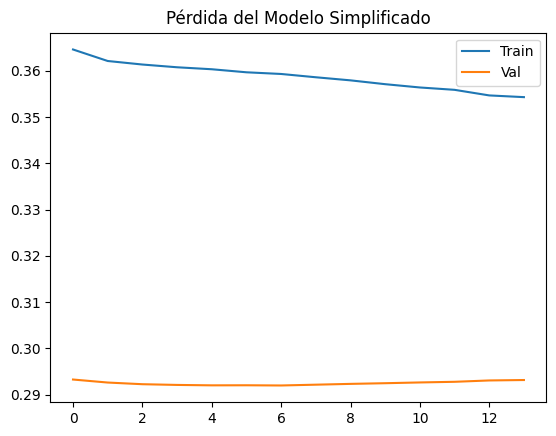

In [7]:
import sys
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas_datareader.data as web
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Concatenate
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# 1. CARGA Y PREPROCESAMIENTO (Igual al original para mantener compatibilidad)
print("1. Cargando datos...")
# Nota: Asegúrate de tener el archivo csv en la ruta correcta
df_ret = pd.read_csv('dataset_ia_log_returns_10y.csv', index_col=0, parse_dates=True)
df_vol = df_ret.rolling(window=21).std()

fecha_inicio, fecha_fin = df_ret.index.min(), df_ret.index.max()
df_fed = web.DataReader('DFF', 'fred', fecha_inicio, fecha_fin)
df_fed.rename(columns={'DFF': 'Tipo_Interes_FED'}, inplace=True)
df_fed['Tipo_Interes_FED'] = df_fed['Tipo_Interes_FED'] / 100

df_master = df_ret.join(df_vol, rsuffix='_vol').join(df_fed, how='left')
df_master['Tipo_Interes_FED'] = df_master['Tipo_Interes_FED'].ffill()
df_master = df_master.dropna()

datos_secuenciales = df_master.drop(columns=['Tipo_Interes_FED']).values
datos_macro = df_master[['Tipo_Interes_FED']].values
datos_y = df_master.iloc[:, :12].values

# 2. ESCALADO
scaler_seq = StandardScaler()
scaler_y = StandardScaler()
scaled_seq = scaler_seq.fit_transform(datos_secuenciales)
scaled_y = scaler_y.fit_transform(datos_y)

# 3. CREACIÓN DE VENTANAS
WINDOW_SIZE = 20
FORECAST_SIZE = 5

def create_hybrid_windows(data_seq, data_macro, data_y, window_size, forecast_size):
    X_seq, X_macro, y = [], [], []
    for i in range(len(data_seq) - window_size - forecast_size + 1):
        X_seq.append(data_seq[i:(i + window_size), :])
        X_macro.append(data_macro[i + window_size - 1, :])
        y.append(data_y[(i + window_size):(i + window_size + forecast_size), :])
    return np.array(X_seq), np.array(X_macro), np.array(y)

X_seq, X_macro, y_windows = create_hybrid_windows(scaled_seq, datos_macro, scaled_y, WINDOW_SIZE, FORECAST_SIZE)

# Split 70/15/15
n = len(X_seq)
train_end, val_end = int(n * 0.70), int(n * 0.85)
X_train_seq, X_train_macro, y_train = X_seq[:train_end], X_macro[:train_end], y_windows[:train_end]
X_val_seq, X_val_macro, y_val = X_seq[train_end:val_end], X_macro[train_end:val_end], y_windows[train_end:val_end]
X_test_seq, X_test_macro, y_test = X_seq[val_end:], X_macro[val_end:], y_windows[val_end:]

# --- NUEVA FUNCIÓN: MODELO SIMPLIFICADO ---
def build_simple_hybrid_model(window_size, num_features, forecast_size, num_assets):
    # Rama 1: Secuencial (LSTM) - Reducida a una sola capa
    input_seq = Input(shape=(window_size, num_features), name="Input_Secuencial")
    x_seq = LSTM(32, activation='tanh', return_sequences=False)(input_seq)
    x_seq = Dropout(0.2)(x_seq)

    # Rama 2: Macro (FED)
    input_macro = Input(shape=(1,), name="Input_FED")
    x_macro = Dense(8, activation='relu')(input_macro)

    # Fusión
    combined = Concatenate()([x_seq, x_macro])

    # Salida: Mapeo directo a (FORECAST_SIZE * num_assets)
    # Usamos una capa densa y luego redimensionamos para que coincida con y
    x = Dense(64, activation='relu')(combined)
    output = Dense(forecast_size * num_assets, activation='linear')(x)
    output = tf.keras.layers.Reshape((forecast_size, num_assets))(output)

    model = Model(inputs=[input_seq, input_macro], outputs=output)
    model.compile(optimizer='adam', loss='huber') # Huber es robusto ante outliers
    return model

# 4. CONSTRUCCIÓN Y ENTRENAMIENTO
print("4. Construyendo modelo simplificado...")
num_features = X_train_seq.shape[2]
model = build_simple_hybrid_model(WINDOW_SIZE, num_features, FORECAST_SIZE, 12)
model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)

history = model.fit(
    [X_train_seq, X_train_macro], y_train,
    validation_data=([X_val_seq, X_val_macro], y_val),
    epochs=50, # Menos epochs por ser más simple
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# 5. EVALUACIÓN Y HIT RATIO
def desnormalizar(pred, shape_orig):
    pred_flat = pred.reshape(-1, 12)
    pred_desnorm = scaler_y.inverse_transform(pred_flat)
    return pred_desnorm.reshape(shape_orig)

y_test_pred_scaled = model.predict([X_test_seq, X_test_macro])
y_test_pred = desnormalizar(y_test_pred_scaled, y_test_pred_scaled.shape)
y_test_real = desnormalizar(y_test, y_test.shape)

def calculate_hit_ratio(y_real, y_pred):
    real_dir = np.sign(y_real.flatten())
    pred_dir = np.sign(y_pred.flatten())
    mask = real_dir != 0
    return np.mean(real_dir[mask] == pred_dir[mask])

hit_test = calculate_hit_ratio(y_test_real, y_test_pred)
print(f"\nHit Ratio en Test: {hit_test*100:.2f}%")

# Gráfico rápido de pérdida
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Pérdida del Modelo Simplificado')
plt.legend()
plt.show()

In [2]:
from tensorflow.keras.utils import plot_model

# Generar el esquema visual
plot_model(
    model,
    to_file='esquema_modelo_simplificado.png',
    show_shapes=True,
    show_layer_names=True,
    rankdir='TB', # 'TB' para vertical, 'LR' para horizontal
    expand_nested=True,
    dpi=96
)

print(model.summary)

<bound method Model.summary of <Functional name=functional, built=True>>


In [8]:
def evaluar_rendimiento(model, X_seq, X_macro, y_real_scaled, scaler, nombre_set):
    # 1. Predicción
    y_pred_scaled = model.predict([X_seq, X_macro], verbose=0)

    # 2. Desnormalización
    # Aplanamos para el scaler y luego recuperamos la forma (N, 5, 12)
    shape_orig = y_pred_scaled.shape
    y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 12)).reshape(shape_orig)
    y_real = scaler.inverse_transform(y_real_scaled.reshape(-1, 12)).reshape(shape_orig)

    # 3. RMSE (Raíz del Error Cuadrático Medio)
    rmse = np.sqrt(mean_squared_error(y_real.flatten(), y_pred.flatten()))

    # 4. Hit Ratio (Acierto Direccional)
    real_dir = np.sign(y_real.flatten())
    pred_dir = np.sign(y_pred.flatten())
    # Filtrar ceros para evitar divisiones o comparaciones neutrales
    mask = real_dir != 0
    hits = np.mean(real_dir[mask] == pred_dir[mask])

    # 5. Mostrar resultados
    print(f"--- Métricas {nombre_set} ---")
    print(f"RMSE:      {rmse:.6f}")
    print(f"Hit Ratio: {hits*100:.2f}%")
    print("-" * 25)

    return rmse, hits

# Ejecución para los tres conjuntos
print("\nEvaluación Final del Modelo:")
rmse_train, hit_train = evaluar_rendimiento(model, X_train_seq, X_train_macro, y_train, scaler_y, "Entrenamiento")
rmse_val, hit_val     = evaluar_rendimiento(model, X_val_seq, X_val_macro, y_val, scaler_y, "Validación")
rmse_test, hit_test   = evaluar_rendimiento(model, X_test_seq, X_test_macro, y_test, scaler_y, "Test")


Evaluación Final del Modelo:
--- Métricas Entrenamiento ---
RMSE:      0.018986
Hit Ratio: 54.54%
-------------------------
--- Métricas Validación ---
RMSE:      0.016491
Hit Ratio: 53.74%
-------------------------
--- Métricas Test ---
RMSE:      0.017580
Hit Ratio: 53.18%
-------------------------


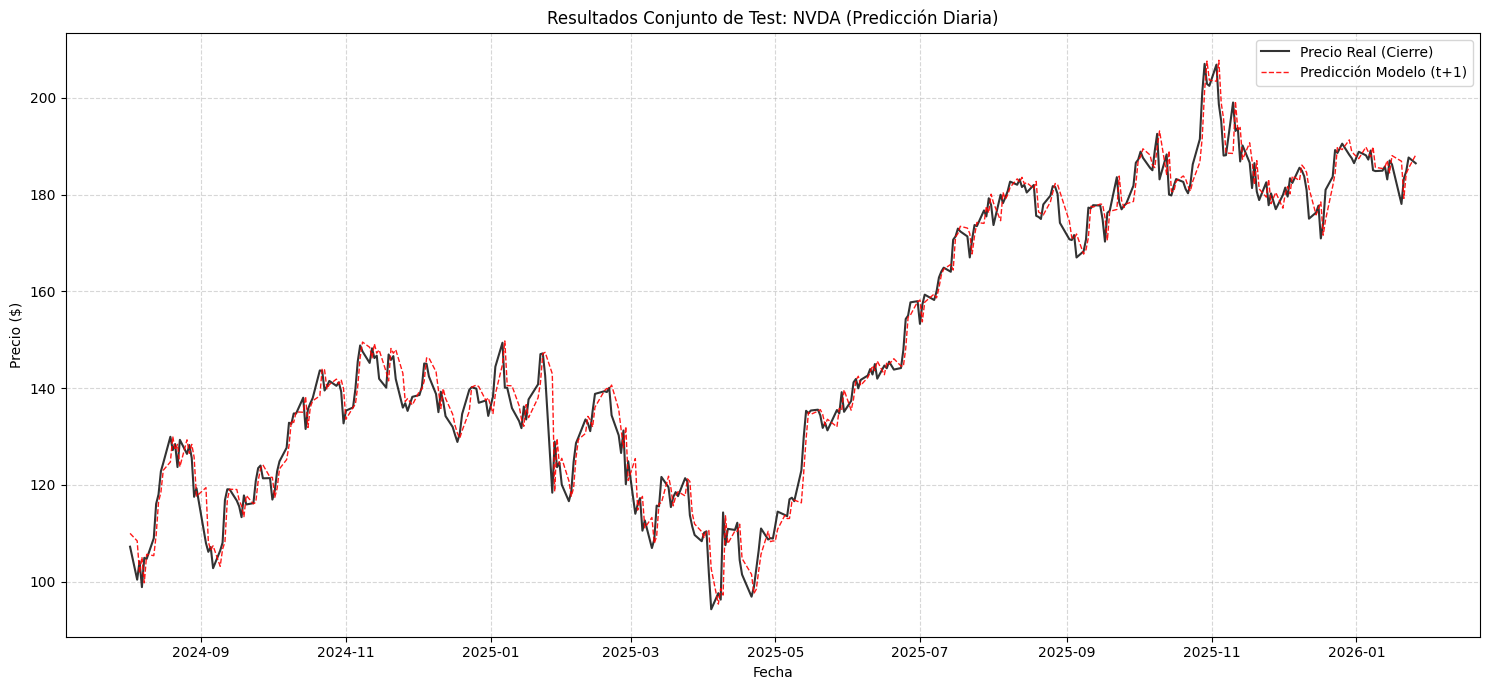

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def graficar_test_completo_precio(asset_index, asset_name, df_precios, y_test_real, y_test_pred, test_dates):
    """
    Grafica todo el conjunto de test comparando el precio real vs la predicción t+1.
    """
    # 1. Extraer precios reales del activo para las fechas de test
    # Nota: Asegúrate de que test_dates coincida exactamente con la longitud de y_test_real
    precios_reales = df_precios[asset_name].loc[test_dates].values

    # 2. Reconstruir el precio predicho (Día +1)
    # y_test_pred tiene forma (N, 5, 12). Tomamos [:, 0, asset_index] para el t+1
    preds_log_t1 = y_test_pred[:, 0, asset_index]

    # El precio predicho para hoy es el precio real de AYER * exp(prediccion_log_ret_hoy)
    # Desplazamos los precios reales un paso atrás para usarlos como base
    precios_base = df_precios[asset_name].shift(1).loc[test_dates].values

    precios_predichos = precios_base * np.exp(preds_log_t1)

    # 3. Crear la gráfica
    plt.figure(figsize=(15, 7))

    # Línea Real
    plt.plot(test_dates, precios_reales, label='Precio Real (Cierre)', color='black', linewidth=1.5, alpha=0.8)

    # Línea Predicción t+1
    plt.plot(test_dates, precios_predichos, label='Predicción Modelo (t+1)', color='red', linestyle='--', linewidth=1, alpha=0.9)

    # Formateo
    plt.title(f'Resultados Conjunto de Test: {asset_name} (Predicción Diaria)')
    plt.xlabel('Fecha')
    plt.ylabel('Precio ($)')
    plt.legend()
    plt.grid(True, which='both', linestyle='--', alpha=0.5)

    # Opcional: Zoom a los últimos 60 días para ver mejor el detalle
    # plt.xlim(test_dates[-60], test_dates[-1])

    plt.tight_layout()
    plt.show()

# --- EJECUCIÓN ---

# 1. Cargar precios
df_precios = pd.read_csv('dataset_ia_precios_cierre_10y.csv', index_col=0, parse_dates=True)

# 2. Definir fechas de test (basado en tu split 70/15/15)
# El dataset original tras el dropna() es df_master
n = len(X_seq)
val_end = int(n * 0.85)
# Las fechas de test corresponden a las etiquetas 'y' que el modelo intentó predecir
# Empezamos en val_end + WINDOW_SIZE para saltar los datos de train/val
test_dates = df_master.index[val_end + WINDOW_SIZE : val_end + WINDOW_SIZE + len(y_test_real)]

# 3. Generar gráfica para NVDA (índice 2 en tu dataset según el snippet)
# Si el orden de tus columnas es [JPM, ETN, NVDA...], NVDA es el índice 2
graficar_test_completo_precio(2, 'NVDA', df_precios, y_test_real, y_test_pred, test_dates)

In [11]:
import pandas as pd
import numpy as np

def analizar_rendimiento_global(y_test_real, y_test_pred, ticker_names):
    """
    Calcula rentabilidades para todos los activos y genera estadísticas.
    """
    resultados = []

    # Recorrer los 12 activos
    for i in range(len(ticker_names)):
        # Extraer retornos t+1 (log-returns)
        ret_real = y_test_real[:, 0, i]
        ret_pred = y_test_pred[:, 0, i]

        # 1. Rentabilidad Buy & Hold
        final_bh = (np.exp(np.sum(ret_real)) - 1) * 100

        # 2. Rentabilidad Long-Short
        # Si pred > 0 -> Largo (+real), Si pred <= 0 -> Corto (-real)
        ret_ls = np.where(ret_pred > 0, ret_real, -ret_real)
        final_ls = (np.exp(np.sum(ret_ls)) - 1) * 100

        # 3. Rentabilidad Long-Only
        ret_lo = np.where(ret_pred > 0, ret_real, 0)
        final_lo = (np.exp(np.sum(ret_lo)) - 1) * 100

        alpha = final_ls - final_bh

        resultados.append({
            'Activo': ticker_names[i],
            'B&H (%)': round(final_bh, 2),
            'Only-Long (%)': round(final_lo, 2),
            'Long-Short (%)': round(final_ls, 2),
            'IA_Gana': 'SÍ' if alpha > 0 else 'NO'
        })

    # Crear DataFrame con los resultados
    df_res = pd.DataFrame(resultados)

    # --- ESTADÍSTICAS ---
    print("      --- ESTADÍSTICAS GLOBALES DEL PORTAFOLIO ---")
    print("-" * 50)
    print(f"Media Rentabilidad Mercado (B&H):    {df_res['B&H (%)'].mean():.2f}%")
    print(f"Media Rentabilidad Modelo (L-S):     {df_res['Long-Short (%)'].mean():.2f}%")
    print(f"Media Rentabilidad Modelo (O-L):     {df_res['Only-Long (%)'].mean():.2f}%")
    print(f"Mejor Activo (Modelo):               {df_res.loc[df_res['Long-Short (%)'].idxmax(), 'Activo']} ({df_res['Long-Short (%)'].max():.2f}%)")
    print(f"Peor Activo (Modelo):                {df_res.loc[df_res['Long-Short (%)'].idxmin(), 'Activo']} ({df_res['Long-Short (%)'].min():.2f}%)")
    print(f"Porcentaje de activos batidos:       {(df_res['IA_Gana'] == 'SÍ').mean()*100:.1f}%")
    print("-" * 50)

    return df_res

# --- USO DEL CÓDIGO ---
# Lista de tus tickers en orden (asegúrate de que coincida con tus columnas del CSV)
tickers = ['JPM', 'ETN', 'NVDA', 'NEE', 'V', 'AMZN', 'MSFT', 'PGR', 'XOM', 'WELL', 'PG', 'WMT']

# Ejecutar análisis
tabla_resultados = analizar_rendimiento_global(y_test_real, y_test_pred, tickers)

# Mostrar la tabla completa
print(tabla_resultados.to_string(index=False))

      --- ESTADÍSTICAS GLOBALES DEL PORTAFOLIO ---
--------------------------------------------------
Media Rentabilidad Mercado (B&H):    31.27%
Media Rentabilidad Modelo (L-S):     28.22%
Media Rentabilidad Modelo (O-L):     29.33%
Mejor Activo (Modelo):               WMT (57.11%)
Peor Activo (Modelo):                XOM (-11.97%)
Porcentaje de activos batidos:       50.0%
--------------------------------------------------
Activo  B&H (%)  Only-Long (%)  Long-Short (%) IA_Gana
   JPM    49.40          39.49           30.24      NO
   ETN    13.37          19.15           25.23      SÍ
  NVDA    70.82          53.58           38.09      NO
   NEE    13.92          22.64           32.02      SÍ
     V    24.89          27.18           29.51      SÍ
  AMZN    29.53          42.60           56.99      SÍ
  MSFT    14.01           8.69            3.61      NO
   PGR     4.89           4.90            4.90      SÍ
   XOM    21.48           3.41          -11.97      NO
  WELL    68.04      

In [12]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

def generar_tabla_auditoria(asset_index, asset_name, y_test_real, y_test_pred):
    """
    Calcula las métricas de auditoría y las presenta en una tabla.
    """
    real = y_test_real[:, 0, asset_index]
    pred = y_test_pred[:, 0, asset_index]

    # Naive Forecast
    naive = np.roll(real, 1)
    naive[0] = 0
    mse_modelo = mean_squared_error(real, pred)
    mse_naive = mean_squared_error(real, naive)
    naive_emoticon = '✅' if mse_modelo < mse_naive else '❌'

    # Correlación
    correlacion = np.corrcoef(real, pred)[0, 1]
    correlacion_emoticon = '✅' if correlacion > 0.5 else '⚠️' if correlacion > 0 else '❌'

    # Media Móvil
    ma_5 = pd.Series(real).rolling(window=5).mean().fillna(0).values
    mse_ma = mean_squared_error(real, ma_5)
    ma_emoticon = '✅' if mse_modelo < mse_ma else '❌'

    data = {
        'Métrica': ['Naive Forecast', 'Correlación', 'Media Móvil (5d)'],
        'Valor Obtenido': [f'{mse_modelo:.6f} (Modelo)', f'{correlacion:.4f}', f'{mse_modelo:.6f} (Modelo)'],
        'Objetivo': [f'<{mse_naive:.6f} (Naive)', '>0.5000', f'<{mse_ma:.6f} (MA 5d)'],
        'Resultado': [naive_emoticon, correlacion_emoticon, ma_emoticon]
    }

    df_auditoria = pd.DataFrame(data)
    print(f"--- AUDITORÍA DE MODELO: {asset_name} ---")
    return df_auditoria

# --- EJECUCIÓN ---
# Asumiendo que 'y_test_real', 'y_test_pred' están disponibles del análisis previo.
# Ejemplo con NVDA (índice 2)
tabla_auditoria_nvda = generar_tabla_auditoria(2, 'NVDA', y_test_real, y_test_pred)
display(tabla_auditoria_nvda)


--- AUDITORÍA DE MODELO: NVDA ---


,Métrica,Valor Obtenido,Objetivo,Resultado
0,Naive Forecast,0.000922 (Modelo),<0.002027 (Naive),✅
1,Correlación,0.0475,>0.5000,⚠️
2,Media Móvil (5d),0.000922 (Modelo),<0.000780 (MA 5d),❌


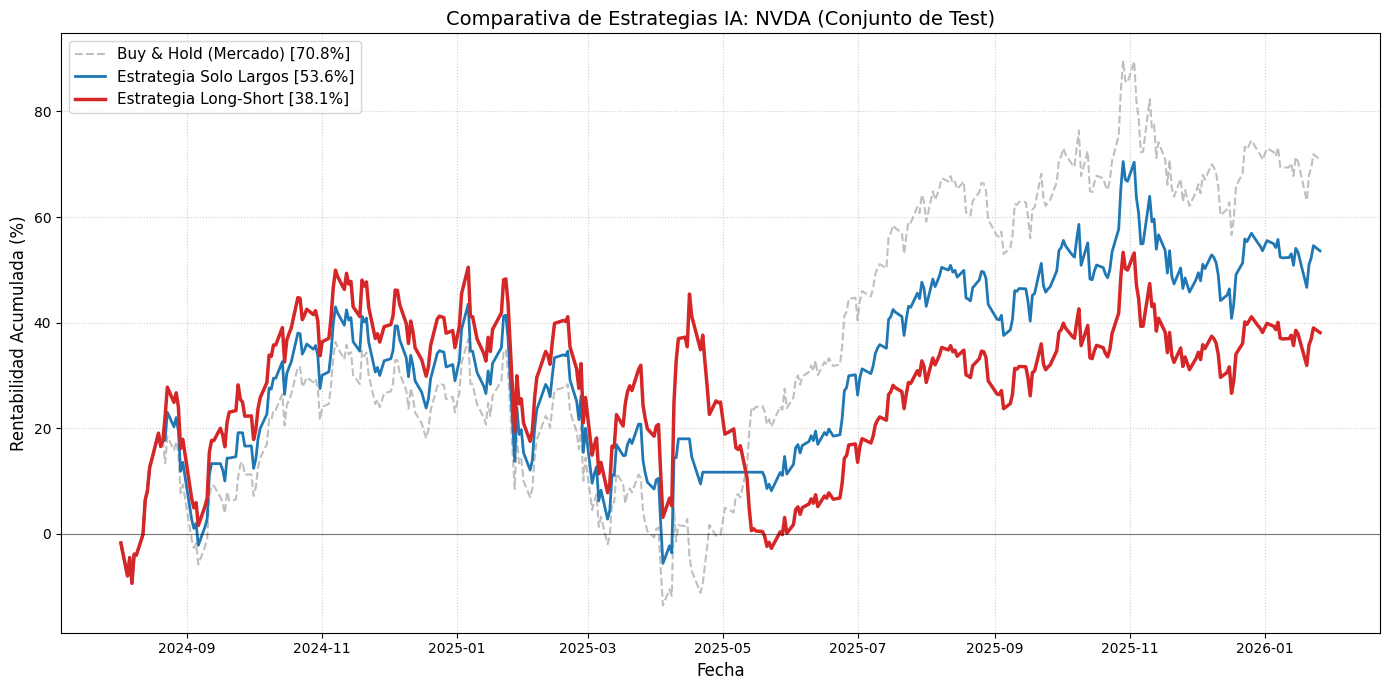

Resultados Finales para NVDA:
  Rentabilidad B&H:        70.82%
  Rentabilidad Solo Largos: 53.58%
  Rentabilidad Long-Short:  38.09%


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def graficar_estrategia_long_short(asset_index, asset_name, y_test_real, y_test_pred, test_dates):
    """
    Calcula y grafica las tres estrategias: Buy & Hold, Solo Largos y Long-Short.
    """
    # 1. Extraer retornos del primer día (t+1) para el activo seleccionado
    # y_test_real/pred tienen forma (N, 5, 12)
    ret_real = y_test_real[:, 0, asset_index]
    ret_pred = y_test_pred[:, 0, asset_index]

    # --- ESTRATEGIA 1: Buy & Hold (Mercado) ---
    # Simplemente acumulamos todos los retornos reales
    cum_bh = np.exp(np.cumsum(ret_real)) - 1

    # --- ESTRATEGIA 2: Solo Largos (Long-Only) ---
    # Si predicción > 0, ganamos/perdemos el real. Si no, 0 (cash).
    ret_lo = np.where(ret_pred > 0, ret_real, 0)
    cum_lo = np.exp(np.cumsum(ret_lo)) - 1

    # --- ESTRATEGIA 3: Long-Short (Bidireccional) ---
    # Si predicción > 0 -> Largo (+ret_real)
    # Si predicción <= 0 -> Corto (-ret_real)
    ret_ls = np.where(ret_pred > 0, ret_real, -ret_real)
    cum_ls = np.exp(np.cumsum(ret_ls)) - 1

    # 2. Configuración del Gráfico
    plt.figure(figsize=(14, 7))

    # Graficar líneas (multiplicamos por 100 para ver porcentaje)
    plt.plot(test_dates, cum_bh * 100, label=f'Buy & Hold (Mercado) [{cum_bh[-1]*100:.1f}%]',
             color='gray', alpha=0.5, linestyle='--')

    plt.plot(test_dates, cum_lo * 100, label=f'Estrategia Solo Largos [{cum_lo[-1]*100:.1f}%]',
             color='#1f77b4', linewidth=2)

    plt.plot(test_dates, cum_ls * 100, label=f'Estrategia Long-Short [{cum_ls[-1]*100:.1f}%]',
             color='#d62728', linewidth=2.5)

    # Personalización
    plt.title(f'Comparativa de Estrategias IA: {asset_name} (Conjunto de Test)', fontsize=14)
    plt.ylabel('Rentabilidad Acumulada (%)', fontsize=12)
    plt.xlabel('Fecha', fontsize=12)
    plt.axhline(0, color='black', linewidth=0.8, alpha=0.5) # Línea de base 0
    plt.legend(loc='upper left', fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

    # Mostrar métricas por consola
    print(f"Resultados Finales para {asset_name}:")
    print(f"  Rentabilidad B&H:        {cum_bh[-1]*100:2.2f}%")
    print(f"  Rentabilidad Solo Largos: {cum_lo[-1]*100:2.2f}%")
    print(f"  Rentabilidad Long-Short:  {cum_ls[-1]*100:2.2f}%")

# --- EJECUCIÓN ---
# Nota: 'y_test_real' e 'y_test_pred' son los arrays desnormalizados que calculaste antes.
# 'test_dates' son los índices de tiempo correspondientes a tu set de test.

# Ejemplo con el activo en la columna 2 (NVDA)
graficar_estrategia_long_short(2, 'NVDA', y_test_real, y_test_pred, test_dates)

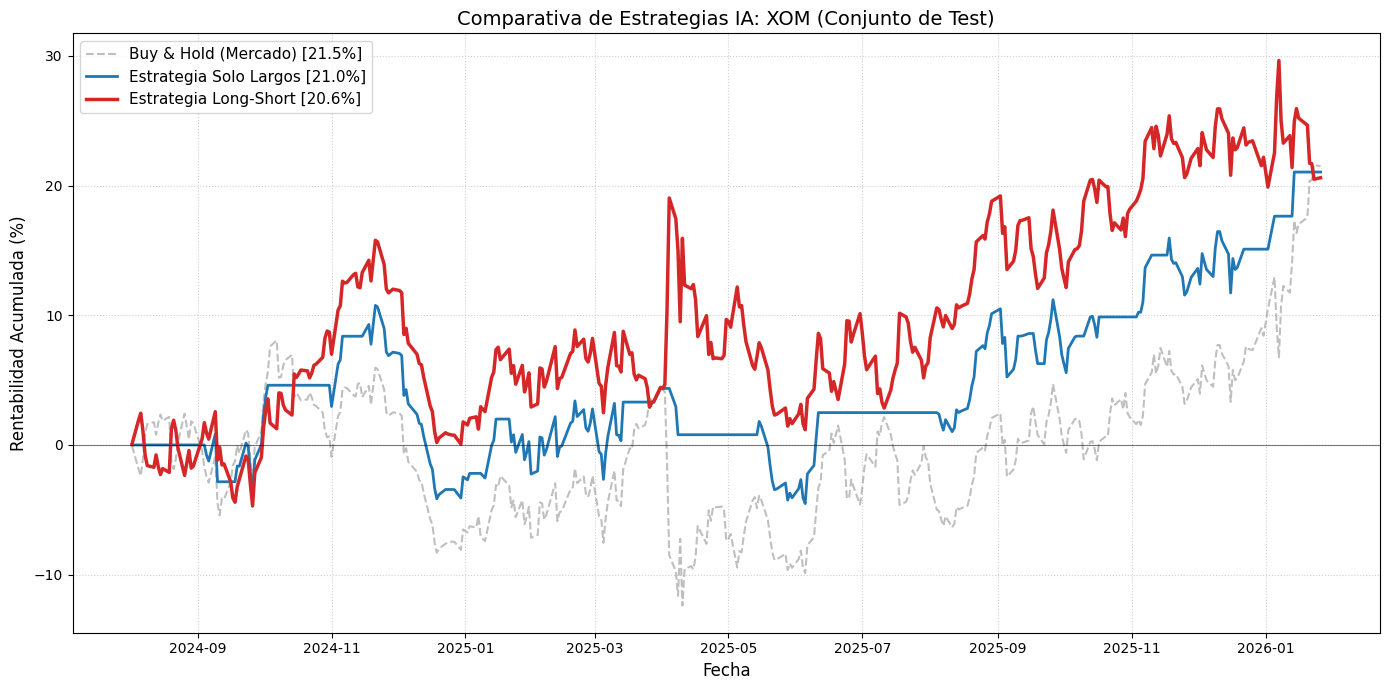

Resultados Finales para XOM:
  Rentabilidad B&H:        21.48%
  Rentabilidad Solo Largos: 21.04%
  Rentabilidad Long-Short:  20.60%


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def graficar_estrategia_long_short(asset_index, asset_name, y_test_real, y_test_pred, test_dates):
    """
    Calcula y grafica las tres estrategias: Buy & Hold, Solo Largos y Long-Short.
    """
    # 1. Extraer retornos del primer día (t+1) para el activo seleccionado
    # y_test_real/pred tienen forma (N, 5, 12)
    ret_real = y_test_real[:, 0, asset_index]
    ret_pred = y_test_pred[:, 0, asset_index]

    # --- ESTRATEGIA 1: Buy & Hold (Mercado) ---
    # Simplemente acumulamos todos los retornos reales
    cum_bh = np.exp(np.cumsum(ret_real)) - 1

    # --- ESTRATEGIA 2: Solo Largos (Long-Only) ---
    # Si predicción > 0, ganamos/perdemos el real. Si no, 0 (cash).
    ret_lo = np.where(ret_pred > 0, ret_real, 0)
    cum_lo = np.exp(np.cumsum(ret_lo)) - 1

    # --- ESTRATEGIA 3: Long-Short (Bidireccional) ---
    # Si predicción > 0 -> Largo (+ret_real)
    # Si predicción <= 0 -> Corto (-ret_real)
    ret_ls = np.where(ret_pred > 0, ret_real, -ret_real)
    cum_ls = np.exp(np.cumsum(ret_ls)) - 1

    # 2. Configuración del Gráfico
    plt.figure(figsize=(14, 7))

    # Graficar líneas (multiplicamos por 100 para ver porcentaje)
    plt.plot(test_dates, cum_bh * 100, label=f'Buy & Hold (Mercado) [{cum_bh[-1]*100:.1f}%]',
             color='gray', alpha=0.5, linestyle='--')

    plt.plot(test_dates, cum_lo * 100, label=f'Estrategia Solo Largos [{cum_lo[-1]*100:.1f}%]',
             color='#1f77b4', linewidth=2)

    plt.plot(test_dates, cum_ls * 100, label=f'Estrategia Long-Short [{cum_ls[-1]*100:.1f}%]',
             color='#d62728', linewidth=2.5)

    # Personalización
    plt.title(f'Comparativa de Estrategias IA: {asset_name} (Conjunto de Test)', fontsize=14)
    plt.ylabel('Rentabilidad Acumulada (%)', fontsize=12)
    plt.xlabel('Fecha', fontsize=12)
    plt.axhline(0, color='black', linewidth=0.8, alpha=0.5) # Línea de base 0
    plt.legend(loc='upper left', fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

    # Mostrar métricas por consola
    print(f"Resultados Finales para {asset_name}:")
    print(f"  Rentabilidad B&H:        {cum_bh[-1]*100:2.2f}%")
    print(f"  Rentabilidad Solo Largos: {cum_lo[-1]*100:2.2f}%")
    print(f"  Rentabilidad Long-Short:  {cum_ls[-1]*100:2.2f}%")

# --- EJECUCIÓN ---
# Nota: 'y_test_real' e 'y_test_pred' son los arrays desnormalizados que calculaste antes.
# 'test_dates' son los índices de tiempo correspondientes a tu set de test.

# Ejemplo con el activo en la columna 2 (NVDA)
graficar_estrategia_long_short(8, 'XOM', y_test_real, y_test_pred, test_dates)

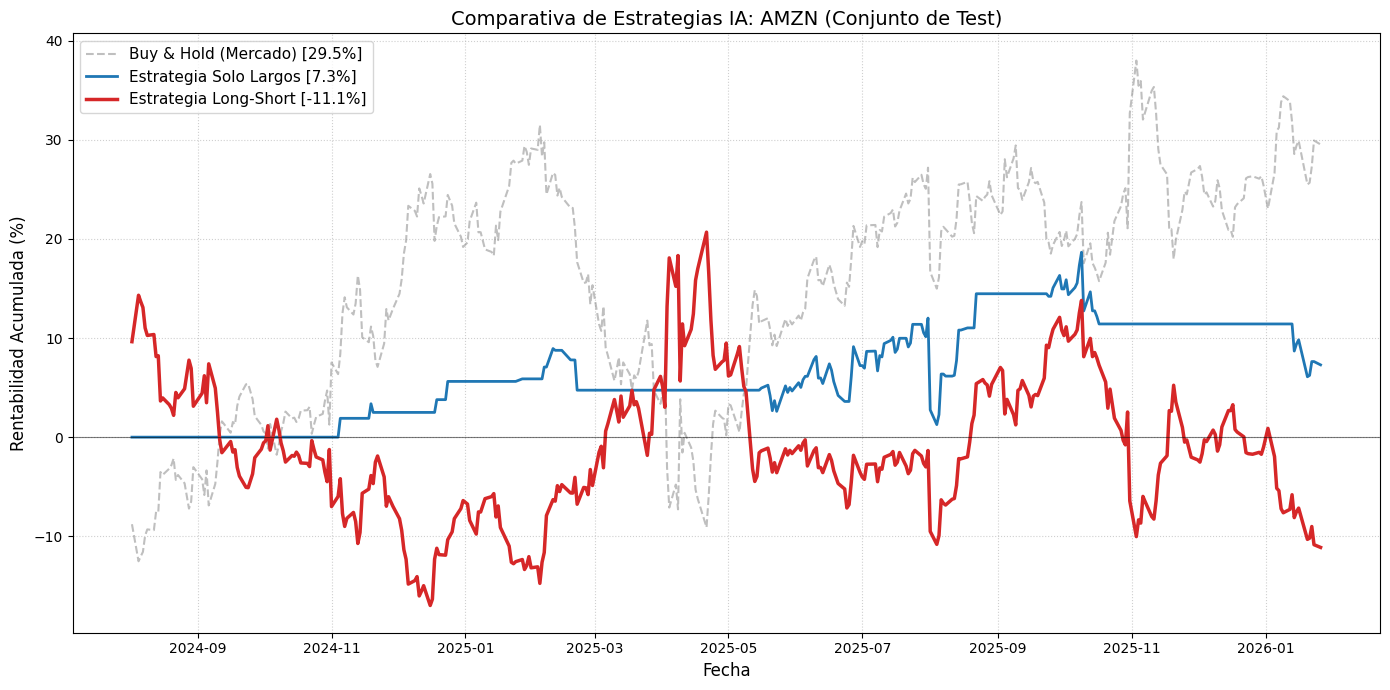

Resultados Finales para AMZN:
  Rentabilidad B&H:        29.53%
  Rentabilidad Solo Largos: 7.29%
  Rentabilidad Long-Short:  -11.12%


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def graficar_estrategia_long_short(asset_index, asset_name, y_test_real, y_test_pred, test_dates):
    """
    Calcula y grafica las tres estrategias: Buy & Hold, Solo Largos y Long-Short.
    """
    # 1. Extraer retornos del primer día (t+1) para el activo seleccionado
    # y_test_real/pred tienen forma (N, 5, 12)
    ret_real = y_test_real[:, 0, asset_index]
    ret_pred = y_test_pred[:, 0, asset_index]

    # --- ESTRATEGIA 1: Buy & Hold (Mercado) ---
    # Simplemente acumulamos todos los retornos reales
    cum_bh = np.exp(np.cumsum(ret_real)) - 1

    # --- ESTRATEGIA 2: Solo Largos (Long-Only) ---
    # Si predicción > 0, ganamos/perdemos el real. Si no, 0 (cash).
    ret_lo = np.where(ret_pred > 0, ret_real, 0)
    cum_lo = np.exp(np.cumsum(ret_lo)) - 1

    # --- ESTRATEGIA 3: Long-Short (Bidireccional) ---
    # Si predicción > 0 -> Largo (+ret_real)
    # Si predicción <= 0 -> Corto (-ret_real)
    ret_ls = np.where(ret_pred > 0, ret_real, -ret_real)
    cum_ls = np.exp(np.cumsum(ret_ls)) - 1

    # 2. Configuración del Gráfico
    plt.figure(figsize=(14, 7))

    # Graficar líneas (multiplicamos por 100 para ver porcentaje)
    plt.plot(test_dates, cum_bh * 100, label=f'Buy & Hold (Mercado) [{cum_bh[-1]*100:.1f}%]',
             color='gray', alpha=0.5, linestyle='--')

    plt.plot(test_dates, cum_lo * 100, label=f'Estrategia Solo Largos [{cum_lo[-1]*100:.1f}%]',
             color='#1f77b4', linewidth=2)

    plt.plot(test_dates, cum_ls * 100, label=f'Estrategia Long-Short [{cum_ls[-1]*100:.1f}%]',
             color='#d62728', linewidth=2.5)

    # Personalización
    plt.title(f'Comparativa de Estrategias IA: {asset_name} (Conjunto de Test)', fontsize=14)
    plt.ylabel('Rentabilidad Acumulada (%)', fontsize=12)
    plt.xlabel('Fecha', fontsize=12)
    plt.axhline(0, color='black', linewidth=0.8, alpha=0.5) # Línea de base 0
    plt.legend(loc='upper left', fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

    # Mostrar métricas por consola
    print(f"Resultados Finales para {asset_name}:")
    print(f"  Rentabilidad B&H:        {cum_bh[-1]*100:2.2f}%")
    print(f"  Rentabilidad Solo Largos: {cum_lo[-1]*100:2.2f}%")
    print(f"  Rentabilidad Long-Short:  {cum_ls[-1]*100:2.2f}%")

# --- EJECUCIÓN ---
# Nota: 'y_test_real' e 'y_test_pred' son los arrays desnormalizados que calculaste antes.
# 'test_dates' son los índices de tiempo correspondientes a tu set de test.

# Ejemplo con el activo en la columna 2 (NVDA)
graficar_estrategia_long_short(5, 'AMZN', y_test_real, y_test_pred, test_dates)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

def auditar_modelo_test(asset_index, asset_name, y_test_real, y_test_pred):
    """
    Evalúa el modelo frente a Naive Forecast, Correlación y Media Móvil.
    """
    # 1. Extraer retornos reales y predichos (t+1)
    real = y_test_real[:, 0, asset_index]
    pred = y_test_pred[:, 0, asset_index]

    # --- MÉTRICA 1: Naive Forecast (y_t+1 = y_t) ---
    # En retornos logarítmicos, el Naive Forecast asume que el retorno de mañana
    # será igual al de hoy. Desplazamos el real un paso.
    naive = np.roll(real, 1)
    naive[0] = 0 # El primer dato no tiene pasado

    mse_modelo = mean_squared_error(real, pred)
    mse_naive = mean_squared_error(real, naive)

    # --- MÉTRICA 2: Correlación de Predicción ---
    # Queremos ver si la dirección y magnitud tienen relación lineal
    correlacion = np.corrcoef(real, pred)[0, 1]

    # --- MÉTRICA 3: Capacidad de respuesta (vs Moving Average) ---
    # Calculamos una media móvil simple de 5 días sobre los reales para comparar
    ma_5 = pd.Series(real).rolling(window=5).mean().fillna(0).values
    mse_ma = mean_squared_error(real, ma_5)

    print(f"--- AUDITORÍA DE MODELO: {asset_name} ---")

    # Verificación Naive
    print(f"\n1. ¿Supera al Naive Forecast (Benchmark de persistencia)?")
    print(f"   MSE Modelo: {mse_modelo:.6f} | MSE Naive: {mse_naive:.6f}")
    if mse_modelo < mse_naive:
        print("   ✅ LOGRADO: El modelo aporta más información que simplemente repetir el ayer.")
    else:
        print("   ❌ NO LOGRADO: El modelo es menos preciso que un pronóstico ingenuo.")

    # Verificación Correlación
    print(f"\n2. ¿Correlación > 0.5?")
    print(f"   Correlación detectada: {correlacion:.4f}")
    if correlacion > 0.5:
        print("   ✅ LOGRADO: Alta capacidad predictiva lineal.")
    elif correlacion > 0:
        print("   ⚠️ PARCIAL: Hay correlación positiva, pero es débil (ruido de mercado).")
    else:
        print("   ❌ NO LOGRADO: El modelo no sigue la dirección del precio.")

    # Verificación vs Media Móvil
    print(f"\n3. ¿Mejor que Media Móvil (Tendencia)?")
    print(f"   MSE Modelo: {mse_modelo:.6f} | MSE Moving Average (5d): {mse_ma:.6f}")
    if mse_modelo < mse_ma:
        print("   ✅ LOGRADO: El modelo reacciona mejor a los giros que una media móvil.")
    else:
        print("   ❌ NO LOGRADO: Una simple media móvil es más precisa.")

# --- EJECUCIÓN ---
auditar_modelo_test(2, 'NVDA', y_test_real, y_test_pred)

--- AUDITORÍA DE MODELO: NVDA ---

1. ¿Supera al Naive Forecast (Benchmark de persistencia)?
   MSE Modelo: 0.000920 | MSE Naive: 0.002027
   ✅ LOGRADO: El modelo aporta más información que simplemente repetir el ayer.

2. ¿Correlación > 0.5?
   Correlación detectada: 0.0259
   ⚠️ PARCIAL: Hay correlación positiva, pero es débil (ruido de mercado).

3. ¿Mejor que Media Móvil (Tendencia)?
   MSE Modelo: 0.000920 | MSE Moving Average (5d): 0.000780
   ❌ NO LOGRADO: Una simple media móvil es más precisa.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

def generar_tabla_auditoria(asset_index, asset_name, y_test_real, y_test_pred):
    """
    Calcula las métricas de auditoría y las presenta en una tabla.
    """
    real = y_test_real[:, 0, asset_index]
    pred = y_test_pred[:, 0, asset_index]

    # Naive Forecast
    naive = np.roll(real, 1)
    naive[0] = 0
    mse_modelo = mean_squared_error(real, pred)
    mse_naive = mean_squared_error(real, naive)
    naive_emoticon = '✅' if mse_modelo < mse_naive else '❌'

    # Correlación
    correlacion = np.corrcoef(real, pred)[0, 1]
    correlacion_emoticon = '✅' if correlacion > 0.5 else '⚠️' if correlacion > 0 else '❌'

    # Media Móvil
    ma_5 = pd.Series(real).rolling(window=5).mean().fillna(0).values
    mse_ma = mean_squared_error(real, ma_5)
    ma_emoticon = '✅' if mse_modelo < mse_ma else '❌'

    data = {
        'Métrica': ['Naive Forecast', 'Correlación', 'Media Móvil (5d)'],
        'Valor Obtenido': [f'{mse_modelo:.6f}', f'{correlacion:.4f}', f'{mse_modelo:.6f}'],
        'Objetivo': [f'<{mse_naive:.6f}', '>0.5000', f'<{mse_ma:.6f}'],
        'Resultado': [naive_emoticon, correlacion_emoticon, ma_emoticon]
    }

    df_auditoria = pd.DataFrame(data)
    print(f"--- AUDITORÍA DE MODELO: {asset_name} ---")
    return df_auditoria

# --- EJECUCIÓN ---
# Asumiendo que 'y_test_real', 'y_test_pred' están disponibles del análisis previo.
# Ejemplo con NVDA (índice 2)
tabla_auditoria_nvda = generar_tabla_auditoria(2, 'NVDA', y_test_real, y_test_pred)
display(tabla_auditoria_nvda)


--- AUDITORÍA DE MODELO: NVDA ---


,Métrica,Valor Obtenido,Objetivo,Resultado
0,Naive Forecast,0.000920,<0.002027,✅
1,Correlación,0.0259,>0.5000,⚠️
2,Media Móvil (5d),0.000920,<0.000780,❌
